In [2]:
import zipfile

with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [9]:
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df['rating'].fillna("Not Rated", inplace=True)

/tmp/ipykernel_737/3216914752.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
/tmp/ipykernel_737/3216914752.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [10]:
df['release_decade'] = (df['release_year'] // 10) * 10

In [11]:
df['is_movie'] = df['type'].apply(lambda x: 1 if x == "Movie" else 0)

In [12]:
top_countries = df['country'].value_counts().head(5)
top_countries

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245


In [13]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


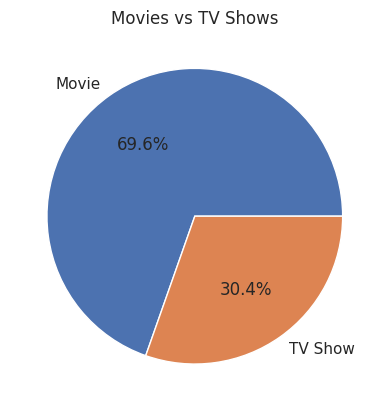

In [14]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

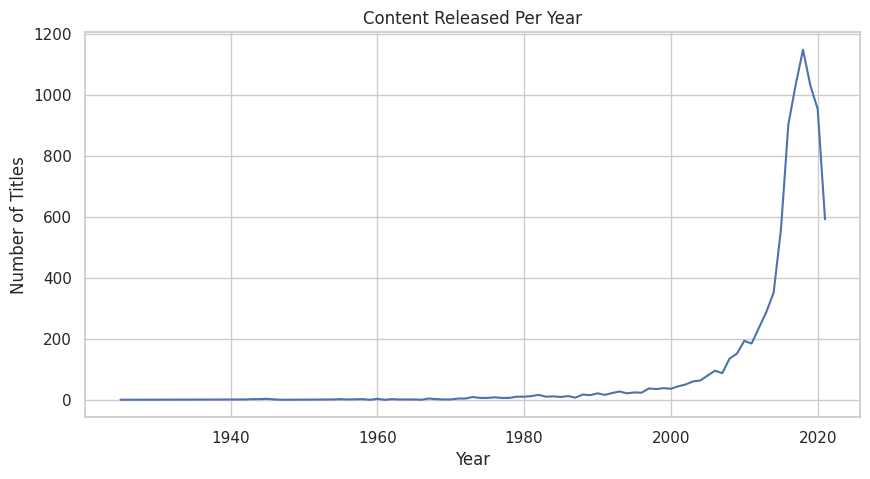

In [15]:
yearly_content = df.groupby('release_year')['title'].count()

plt.figure(figsize=(10,5))
plt.plot(yearly_content)
plt.title("Content Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

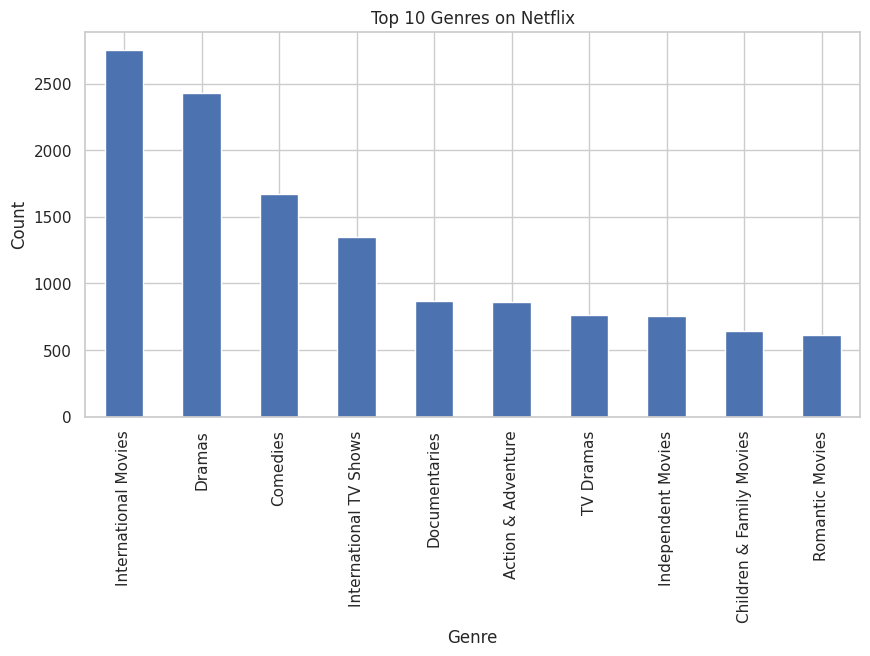

In [16]:
plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

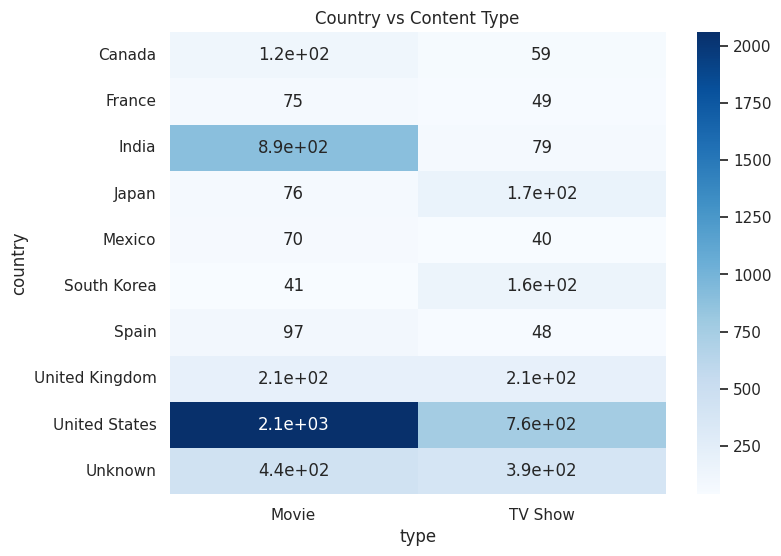

In [17]:
top10_countries = df['country'].value_counts().head(10).index
country_data = df[df['country'].isin(top10_countries)]

ct = pd.crosstab(country_data['country'], country_data['type'])

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, cmap='Blues')
plt.title("Country vs Content Type")
plt.show()

### Key Insights

1. Movies make up a larger percentage of Netflix content compared to TV shows.
2. Content production increased significantly after 2015.
3. The United States contributes the highest number of titles.
4. Drama and International genres are among the most popular.
5. Netflix expanded aggressively in the last decade.

In [18]:
yearly_content.tail(5)

,title
release_year,
2017,1032
2018,1147
2019,1030
2020,953
2021,592


In [19]:
df.to_csv("cleaned_netflix_data.csv", index=False)

In [20]:
from google.colab import files
files.download("cleaned_netflix_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>